[2026-08-05 02:16:24] [info     ] 计算因子，区间：2021-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-08-05 02:17:06] [info     ] 读取因子库，区间：2021-01-01 00:00:00 ~ 2024-12-31 23:59:59
[2026-08-05 02:17:06] [warning  ] bigalpha_eval._latest version='v4' (use ._latest for dev only, not for prod)
[2026-08-05 02:17:13] [info     ] bigalpha_eval.v4 开始运行 ..
[2026-08-05 02:17:14] [warning  ] 未传入官方评估窗口 start_date/end_date，回退到数据自身范围（仅建议本地调试时使用）
[2026-08-05 02:17:15] [info     ] 对齐中证1000历史成分后，官方评估窗口: 2021-01-04 至 2024-12-31
[2026-08-05 02:17:15] [info     ] ========== 数据检查 ==========
[2026-08-05 02:17:15] [info     ] 通过：列名检查（date/instrument + 至少 1 个因子列） factor_cols=['factor', 'close', 'volume', 'amount', 'turn', 'change_ratio', 'daily_return', 'momentum_5', 'reversal_5', 'volatility_5', 'total_market_cap', 'float_market_cap', 'pe_ttm', 'pb', 'ps_ttm', 'sma_20', 'ema_20', 'macd_diff_12_26_9', 'macd_dea_12_26_9', 'macd_hist_12_26_9', 'rsi_12', 'kdj_k_9_3_3', 'kdj_d_9_3_3', 'bias_20', 'cci_14', 'atr_14', 'roe_avg

时段,IC
2024-01-15~2024-02-08,0.0120
2024-09-24~2024-10-08,0.0304

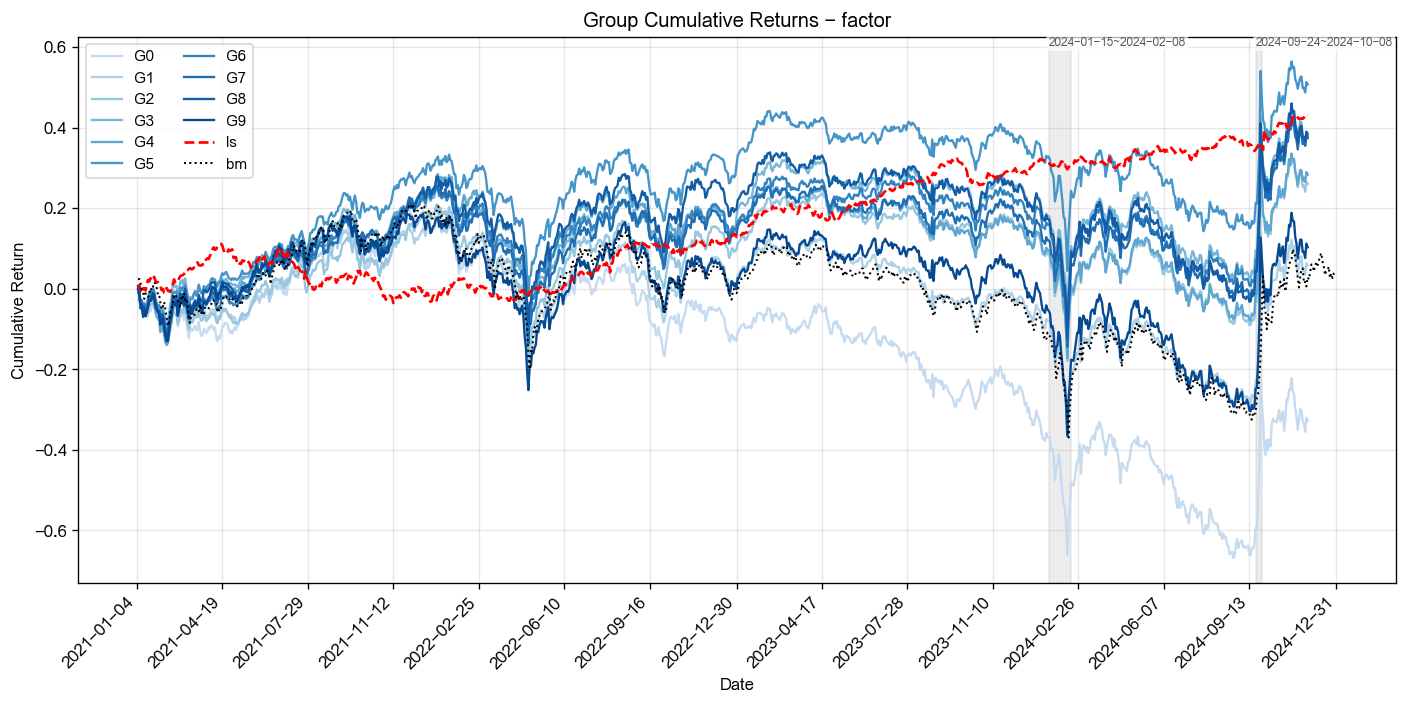
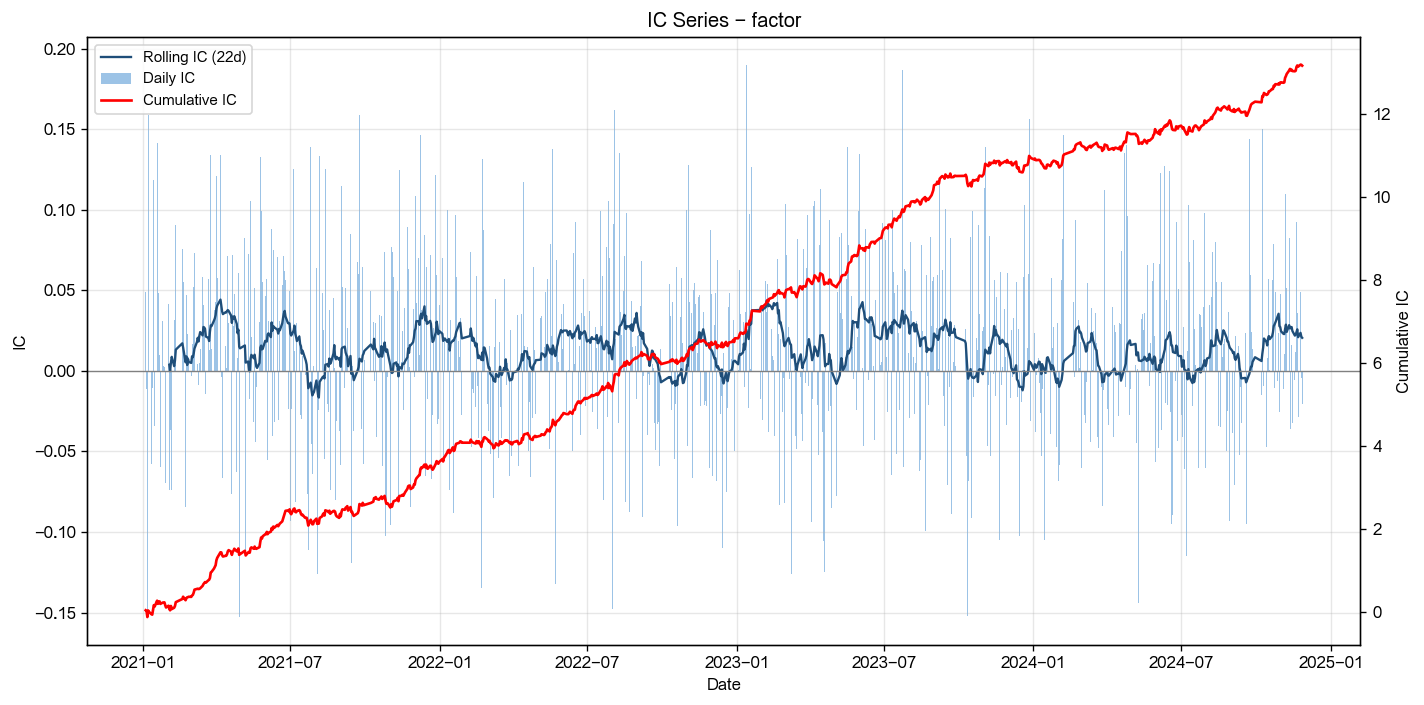
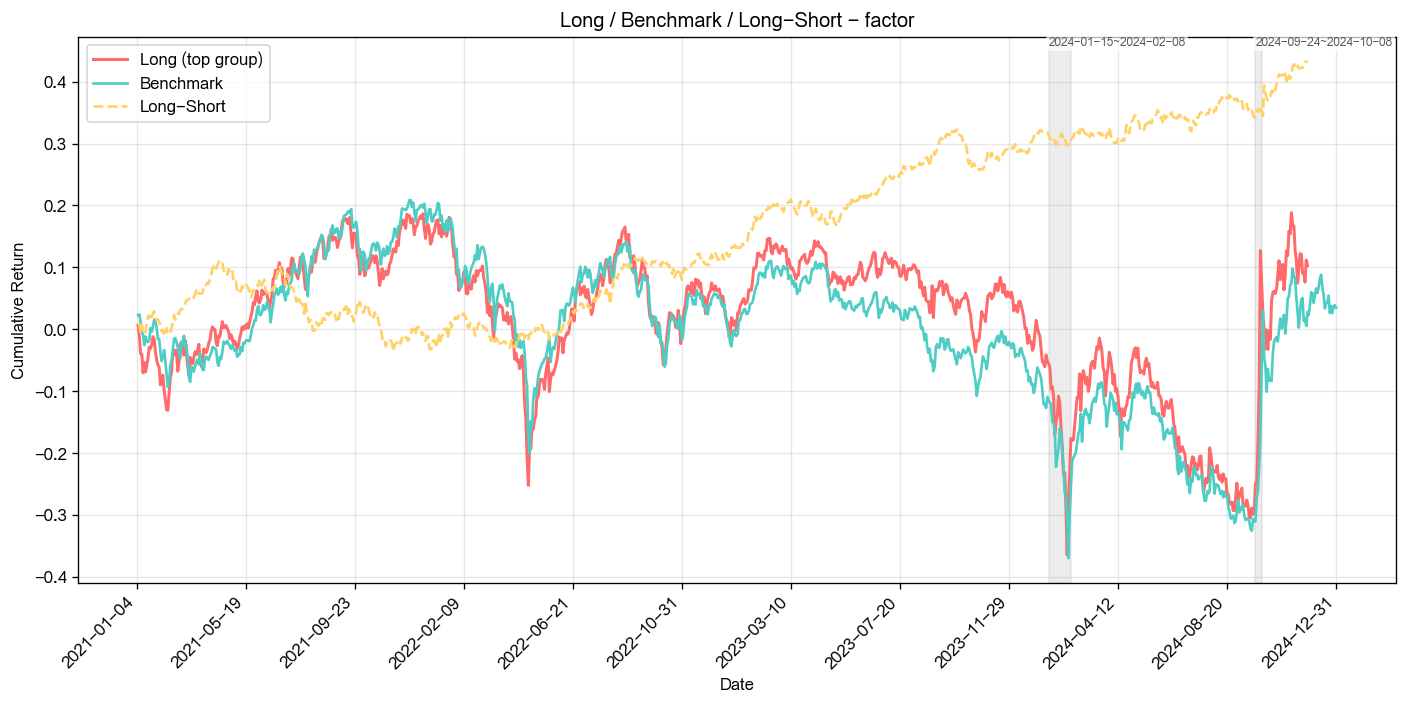
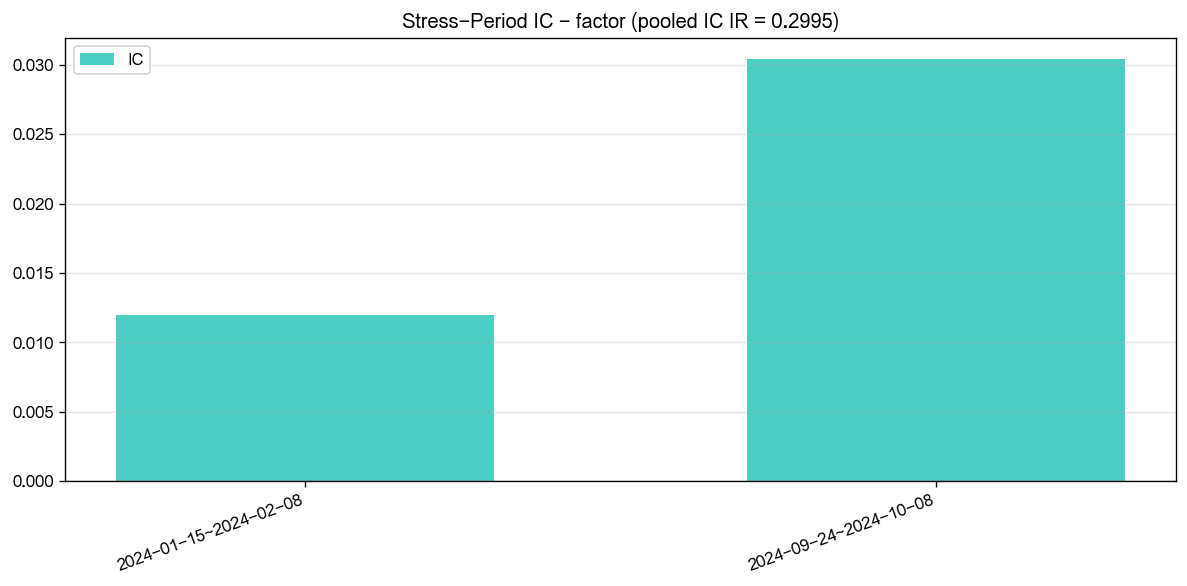
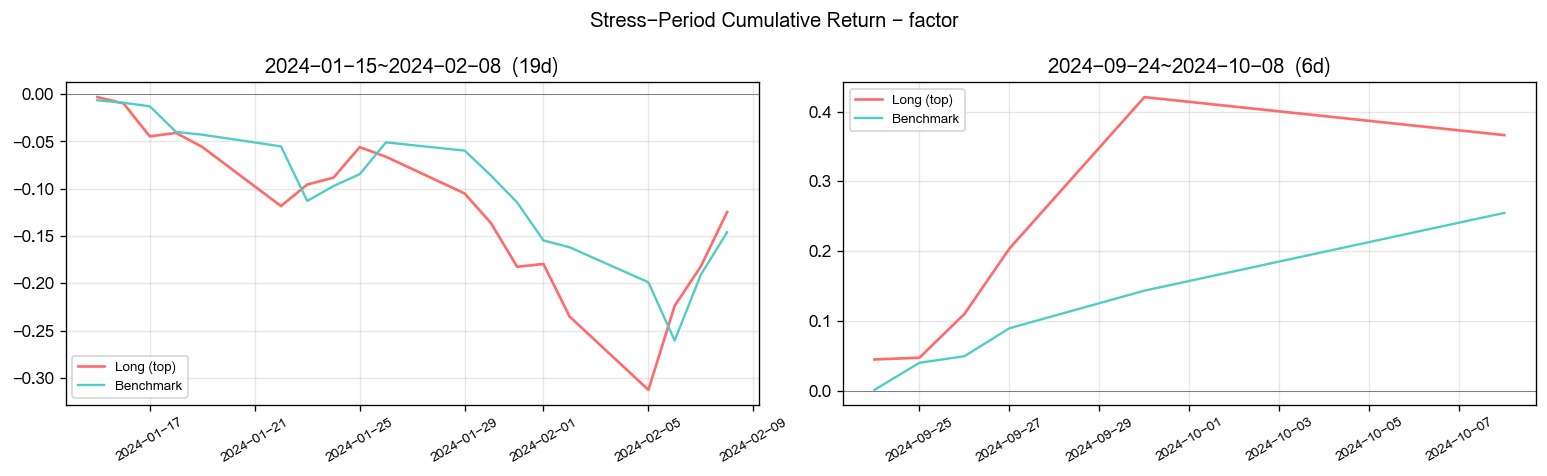

[2026-08-05 02:18:44] [info     ] ========== 因子池回归 ==========
[2026-08-05 02:18:44] [info     ] 加载 T+1 收益数据完成                  end_date=2024-12-31 instrument_count=1753 rows=1604641 start_date=2021-01-04
[2026-08-05 02:18:46] [info     ] 获取收益率数据, 耗时: 2.0366 秒
[2026-08-05 02:18:48] [info     ] 滚动 Elastic Net 拟合, 耗时: 2.314 秒
[2026-08-05 02:18:48] [info     ] 统计 回归结果, 耗时: 0.0066 秒


#,因子名,ModelScore,mean(|w|),std(|w|),入选率
1,momentum_5,1.4591,0.0174,0.0119,0.9783
2,debt_to_asset_lf,1.4543,0.0092,0.0063,0.9783
3,net_active_buy_amount_main,1.4175,0.0202,0.0142,0.9565
4,amount,1.4164,0.0244,0.0172,0.9348
5,gross_profit_rate_ttm,1.3895,0.0127,0.0091,0.9783
6,volatility_5,1.3785,0.0140,0.0101,0.9565
7,bias_20,1.3553,0.0278,0.0205,0.9348
8,beta_000300SH_22,1.3354,0.0175,0.0131,0.9565
9,reversal_5,1.3236,0.0085,0.0064,0.9565
10,macd_hist_12_26_9,1.3205,0.0091,0.0069,0.8913

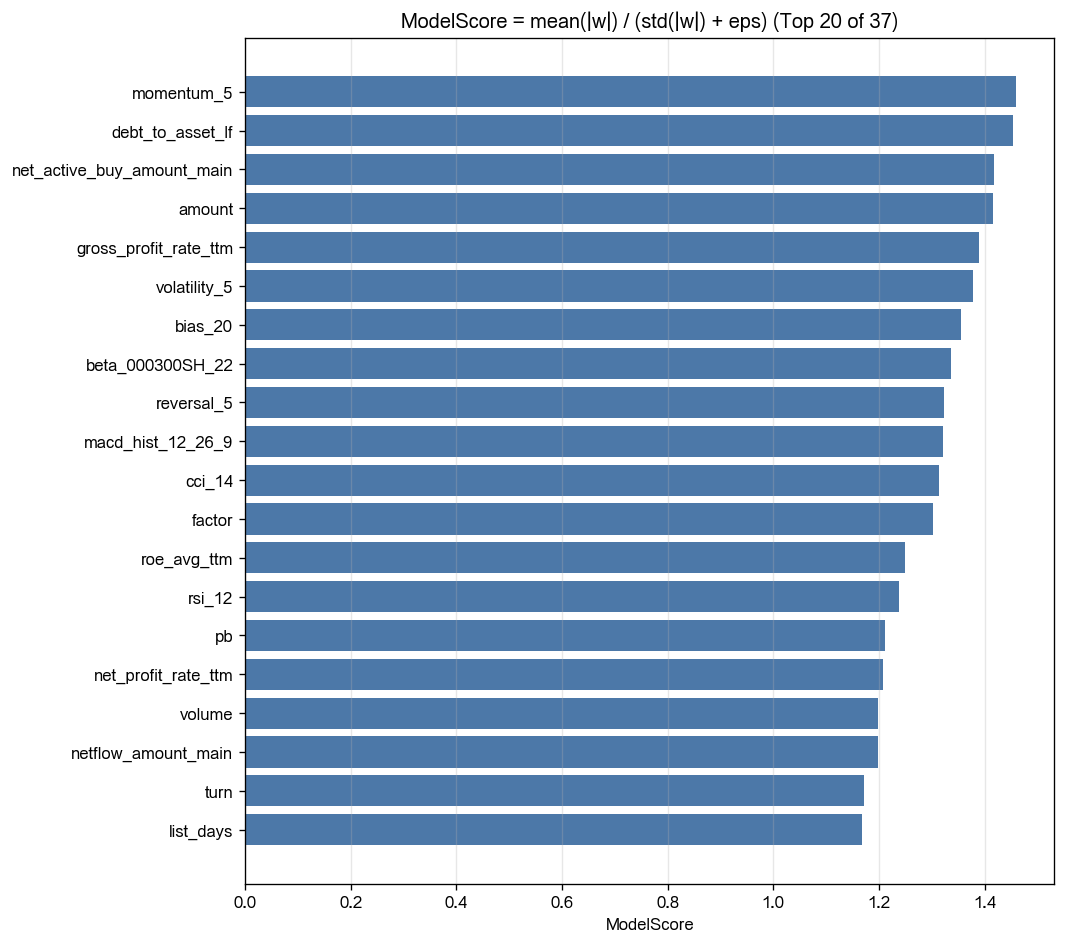
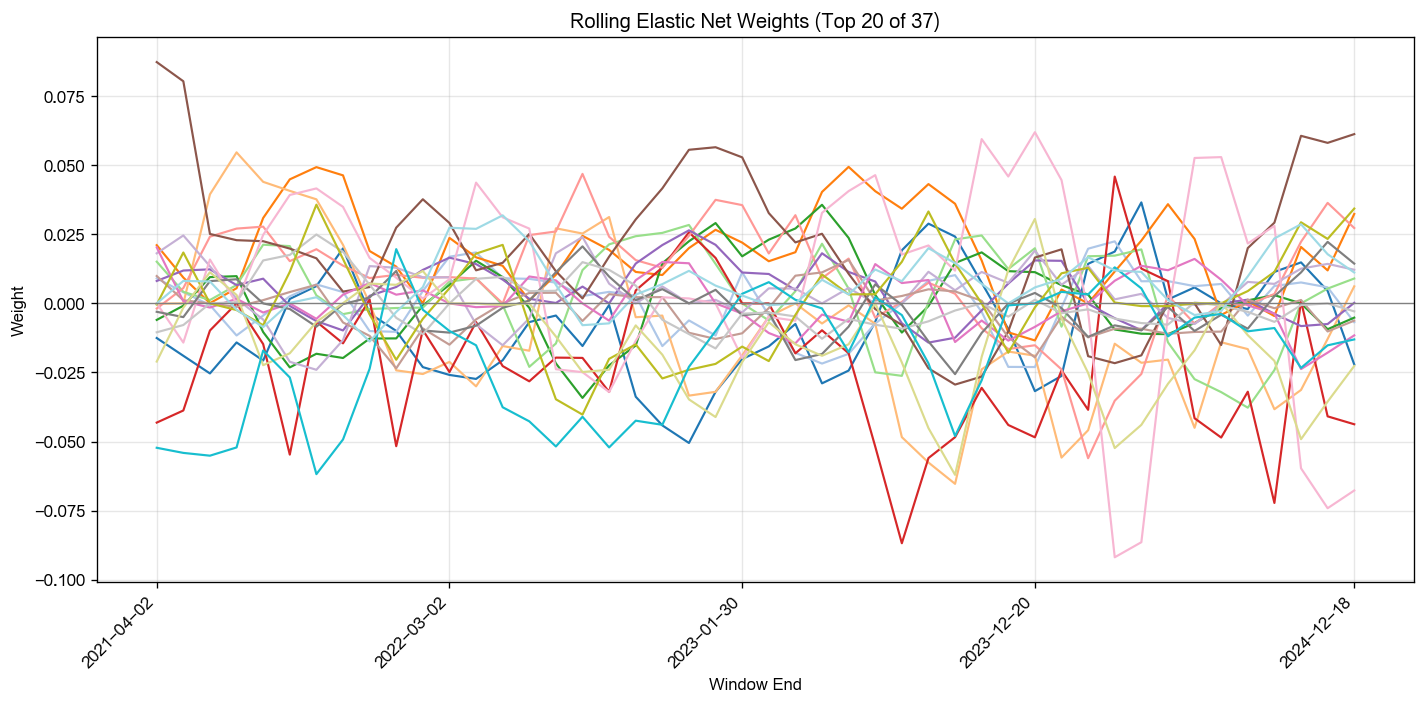
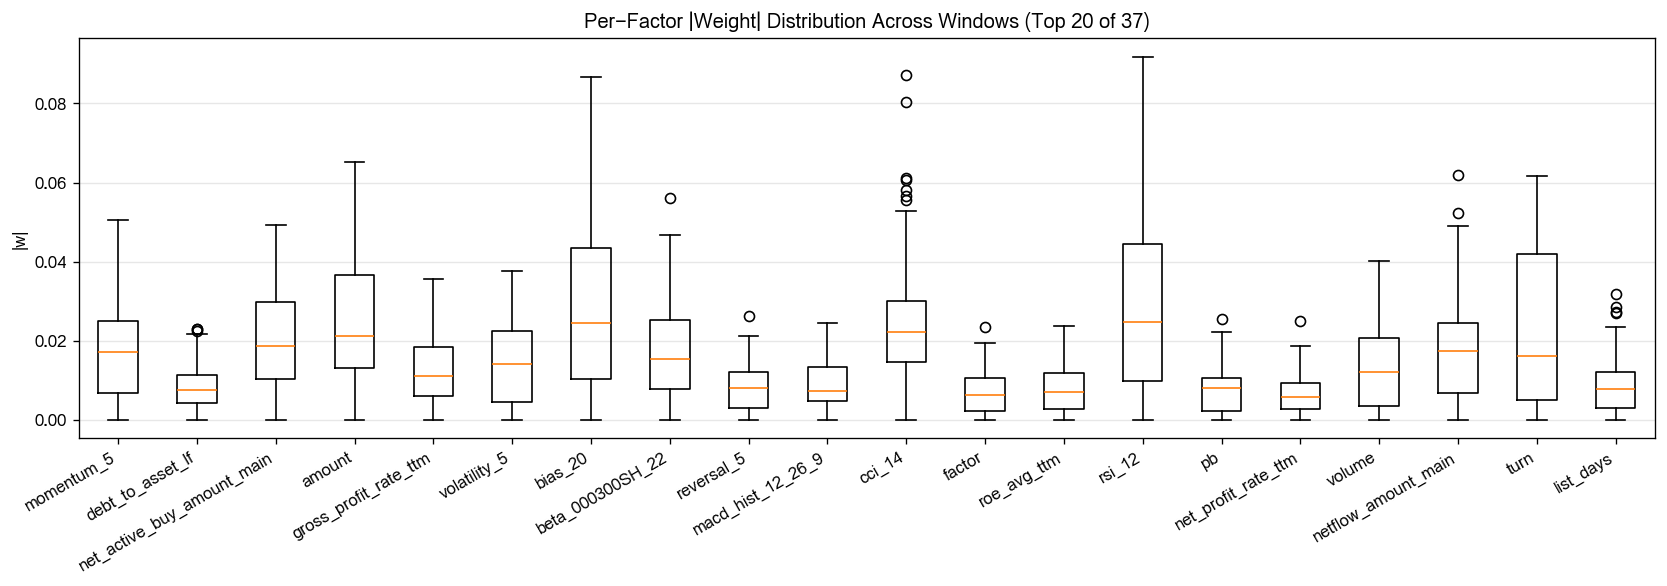
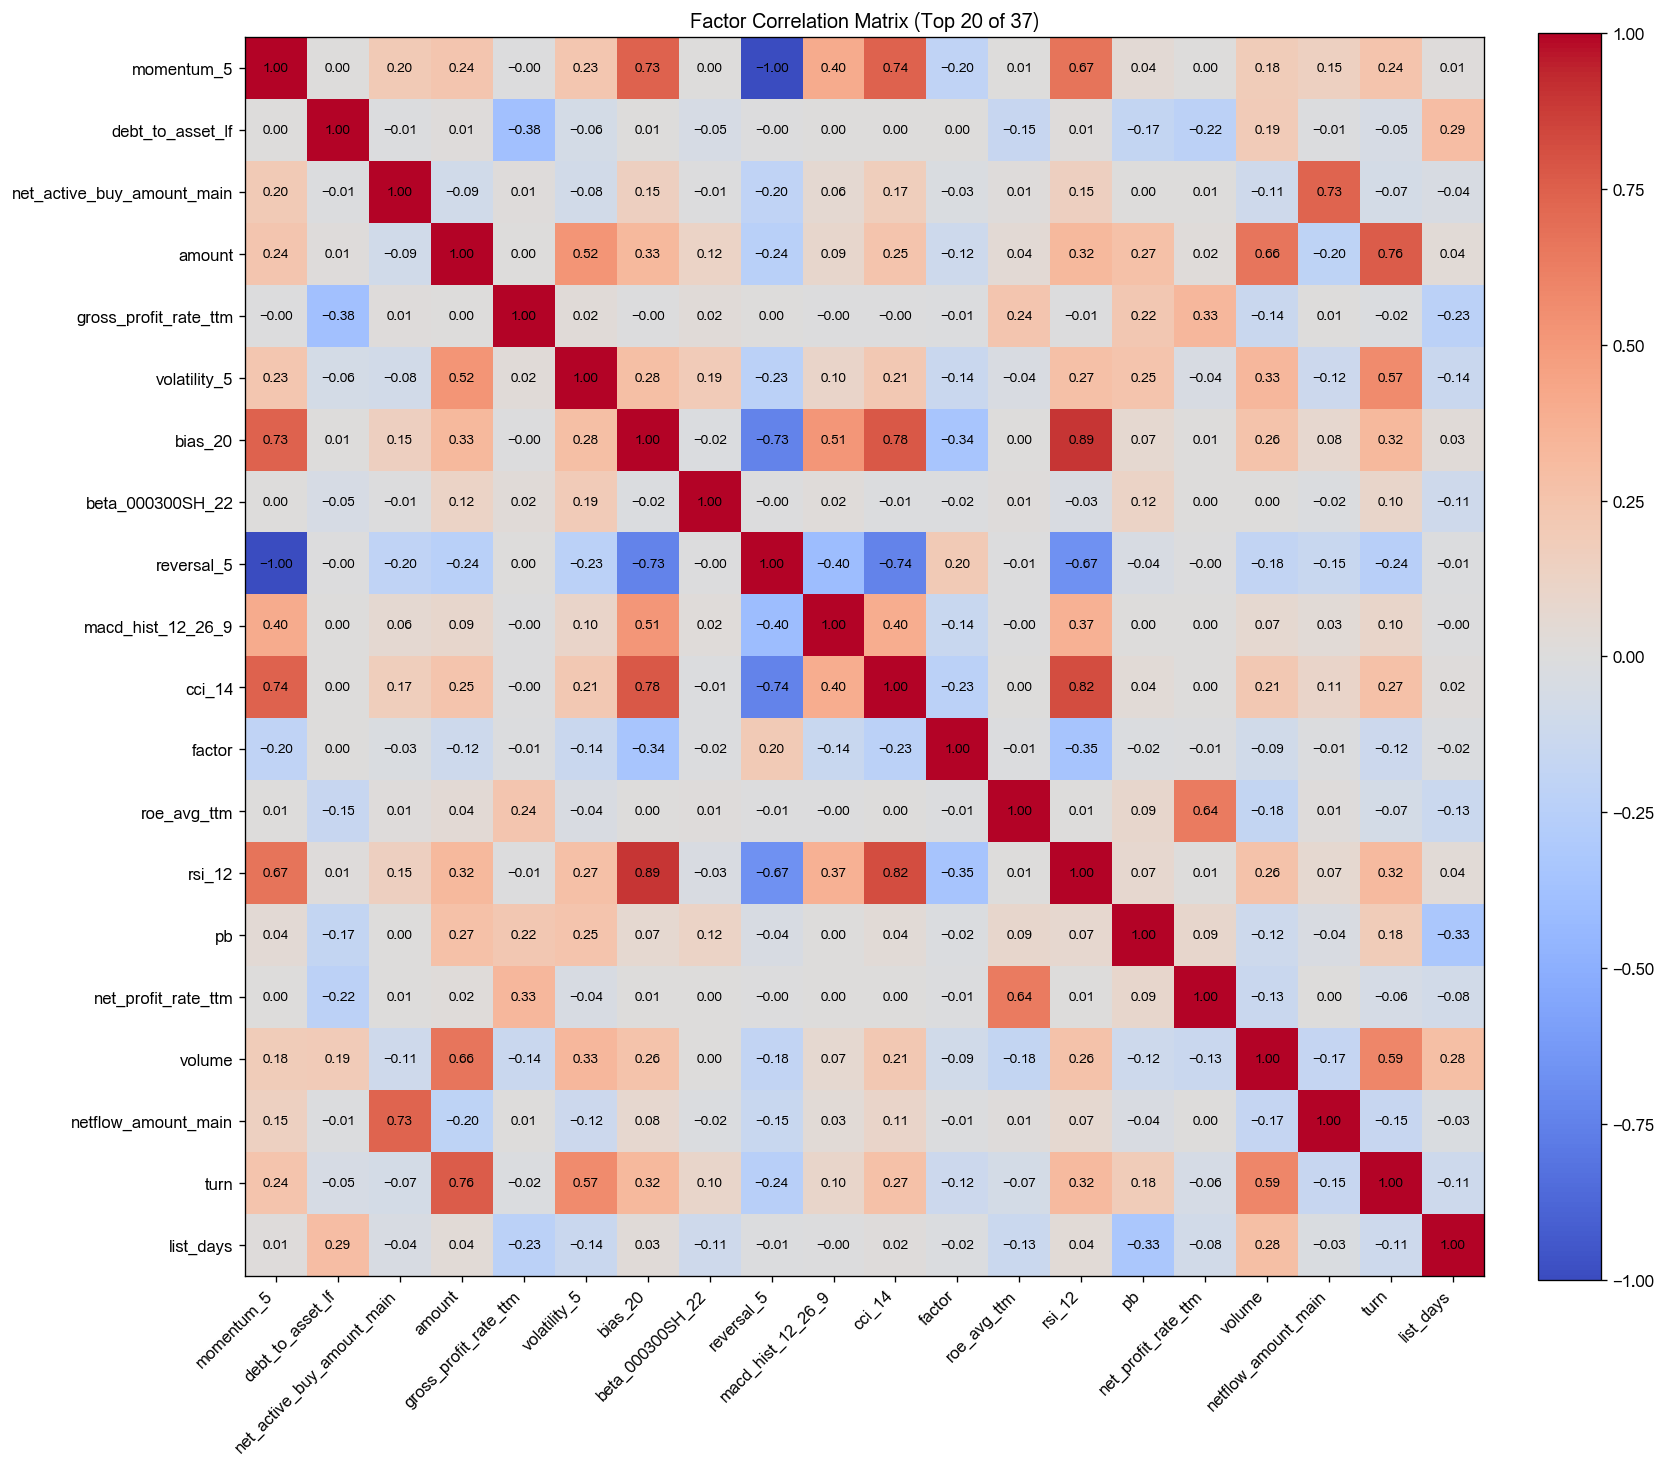

[2026-08-05 02:18:51] [warning  ] 返回的Outputs实例(size=143396954) 大于 64K, 将不会被缓存
[2026-08-05 02:18:51] [info     ] bigalpha_eval.v4 运行完成 [97.239s].


In [2]:
"""
开源证券研报复现（因子切割论）
（1）对选定股票，回溯取其过去20日的数据；
（2）计算该股票每日的平均单笔成交金额（成交金额/成交笔数）；
（3）单笔成交金额高的10个交易日，涨跌幅加总，记作 M_high；
（4）单笔成交金额低的10个交易日，涨跌幅加总，记作 M_low；
（5）理想反转因子 M = M_high–M_low；
（6）对所有股票，都进行以上操作，计算每只股票的理想反转因子M。
"""
def main(datasources, start_date, end_date):
    import numpy as np
    import pandas as pd
    import dai

    bar1m_table = datasources["bar1m"]

    sd = pd.to_datetime(start_date)
    ed = pd.to_datetime(end_date)
    price_start = (sd - pd.Timedelta(days=60)).strftime("%Y-%m-%d %H:%M:%S")

    price_sql = f"""
    SELECT
        date_trunc('day', date)::DATE           AS trading_day,
        instrument,
        ARG_MIN(open, date)                     AS open,
        MAX(high)                               AS high,
        MIN(low)                                AS low,
        ARG_MAX(close, date)                    AS close,
        SUM(volume)                             AS volume,
        SUM(amount)                             AS amount,
        COUNT(*)                                AS trade_count
    FROM {bar1m_table}
    GROUP BY trading_day, instrument
    ORDER BY trading_day, instrument
    """
    df = (
        dai.query(price_sql, filters={"date": [price_start, end_date]})
        .df()
        .rename(columns={"trading_day": "date"})
    )
    df["date"] = pd.to_datetime(df["date"])
    df["instrument"] = df["instrument"].astype(str)

    for c in ["close", "amount", "trade_count"]:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    df = df.replace([np.inf, -np.inf], np.nan)

    df = df.sort_values(["instrument", "date"]).reset_index(drop=True)
    df["ret1d"] = df.groupby("instrument", group_keys=False)["close"].pct_change()

    df["avg_ticket_amt"] = df["amount"] / df["trade_count"]
    df.loc[df["trade_count"] <= 0, "avg_ticket_amt"] = np.nan
    df["avg_ticket_amt"] = df["avg_ticket_amt"].replace([np.inf, -np.inf], np.nan)

    df = df[["date", "instrument", "avg_ticket_amt", "ret1d"]].dropna(
        subset=["avg_ticket_amt", "ret1d"]
    )

    def _ideal_reversal_one_inst_safe(g: pd.DataFrame) -> pd.DataFrame:
        g = g.sort_values("date").reset_index(drop=True)
        n = len(g)
        out = np.full(n, np.nan, dtype="float64")
        avg = g["avg_ticket_amt"].to_numpy(dtype="float64", copy=False)
        ret = g["ret1d"].to_numpy(dtype="float64", copy=False)

        for i in range(19, n):
            a = avg[i - 19 : i + 1]
            r = ret[i - 19 : i + 1]
            mask = np.isfinite(a) & np.isfinite(r)
            if mask.sum() < 20:
                continue
            a = a[mask]
            r = r[mask]
            top_idx = np.argpartition(a, -10)[-10:]
            bot_idx = np.argpartition(a, 10)[:10]
            out[i] = r[top_idx].sum() - r[bot_idx].sum()

        res = g[["date", "instrument"]].copy()
        res["factor"] = out
        return res

    factor_df = df.groupby("instrument", group_keys=False).apply(
        _ideal_reversal_one_inst_safe
    )

    factor_df = factor_df[(factor_df["date"] >= sd) & (factor_df["date"] <= ed)]
    factor_df["factor"] = (
        pd.to_numeric(factor_df["factor"], errors="coerce")
        .replace([np.inf, -np.inf], np.nan)
    )

    stk_pool = dai.query(
        "SELECT date, instrument FROM bigalpha_2026_instruments",
        filters={"date": [start_date, end_date]},
    ).df()
    stk_pool["date"] = pd.to_datetime(stk_pool["date"])
    stk_pool["instrument"] = stk_pool["instrument"].astype(str)

    result = pd.merge(factor_df, stk_pool, how="inner", on=["date", "instrument"])
    result = result.dropna(subset=["factor"]).reset_index(drop=True)[
        ["date", "instrument", "factor"]
    ]

    result['factor'] = (-1) * result['factor']

    return result


if __name__ == "__main__":
    from bigmodule import M
    import dai
    import structlog

    logger = structlog.get_logger()

    datasources = {
        "bar1m": "bigalpha_2026_stock_bar1m",
        "financial": "bigalpha_2026_financial",
    }
    start_date = "2021-01-01 00:00:00"
    end_date = "2024-12-31 23:59:59"

    logger.info(f"计算因子，区间：{start_date} ~ {end_date}")
    factor_data = main(datasources, start_date, end_date)

    logger.info(f"读取因子库，区间：{start_date} ~ {end_date}")
    factor_pool = dai.query(
        "SELECT * FROM bigalpha_2026_factorlib",
        filters={"date": [start_date, end_date]},
    ).df()

    result = M.bigalpha_eval._latest(
        factor_data=factor_data,
        factor_pool=factor_pool,
        process_pools=False,
        show=True,
    )